**SCENARIO 1 – MULTILINEAR REGRESSION**

SHAILESH GOWTHAM - 24BAD108
MSE: 207.91715060774996
RMSE: 14.419332529897144
R2 Score: 0.030085923188504338
                             Coefficient
parental level of education    -1.006718
test preparation course        -3.840039
Selected Features (RFE): Index(['parental level of education', 'test preparation course'], dtype='object')
Ridge Score: 0.030111959480189632
Lasso Score: 0.029790908574382935


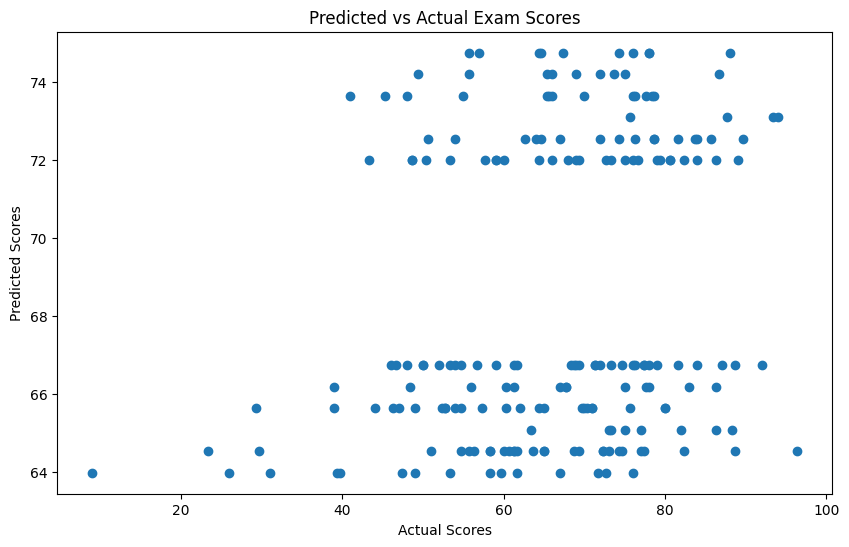

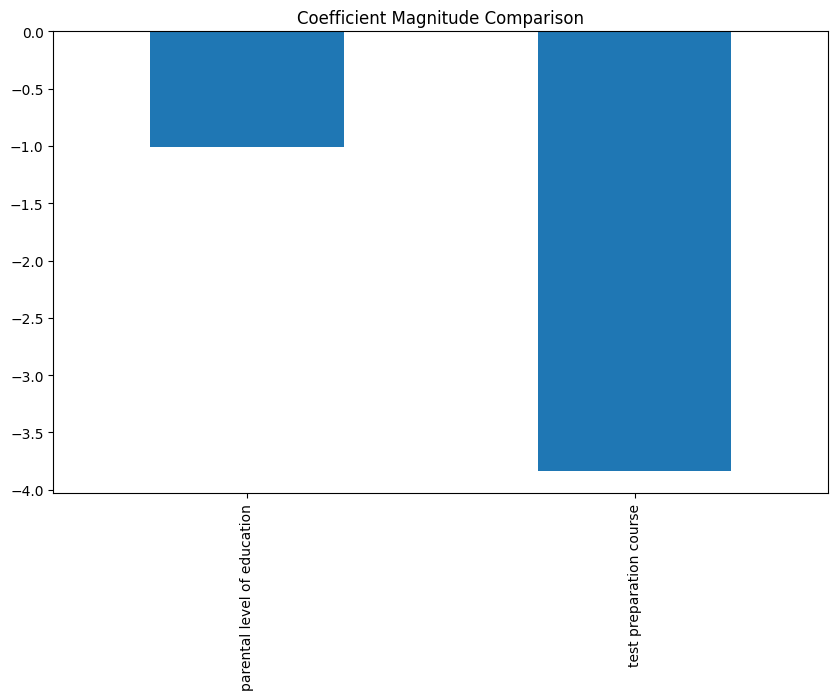

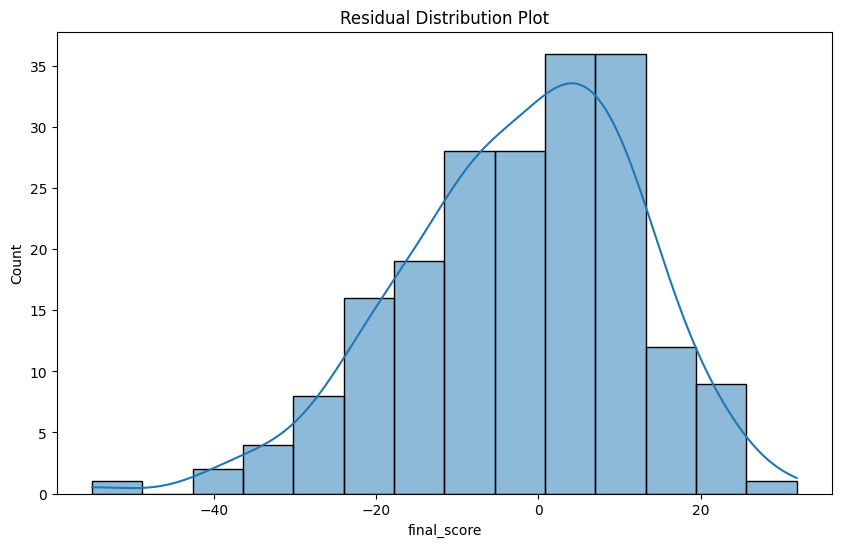

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score

print("SHAILESH GOWTHAM - 24BAD108")

df = pd.read_csv('StudentsPerformance.csv')

df['final_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

le = LabelEncoder()
df['parental level of education'] = le.fit_transform(df['parental level of education'])
df['test preparation course'] = le.fit_transform(df['test preparation course'])

X = df[['parental level of education', 'test preparation course']]
y = df['final_score']

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=2) # Changed to 2 features
rfe.fit(X_train, y_train)
print("Selected Features (RFE):", X.columns[rfe.support_])

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge Score:", ridge.score(X_test, y_test))

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
print("Lasso Score:", lasso.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Predicted vs Actual Exam Scores')
plt.show()

plt.figure(figsize=(10, 6))
coefficients['Coefficient'].plot(kind='bar')
plt.title('Coefficient Magnitude Comparison')
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution Plot')
plt.show()

**SCENARIO 2 – POLYNOMIAL REGRESSION**

SHAILESH GOWTHAM - 24BAD108
Degree 2 - MSE: 18.41696779601778, RMSE: 4.291499481069266, R2: 0.6391701147013314
Degree 3 - MSE: 18.46026722222463, RMSE: 4.296541309265469, R2: 0.6383217814053861
Degree 4 - MSE: 18.268226874853184, RMSE: 4.274134634619409, R2: 0.6420842844016577


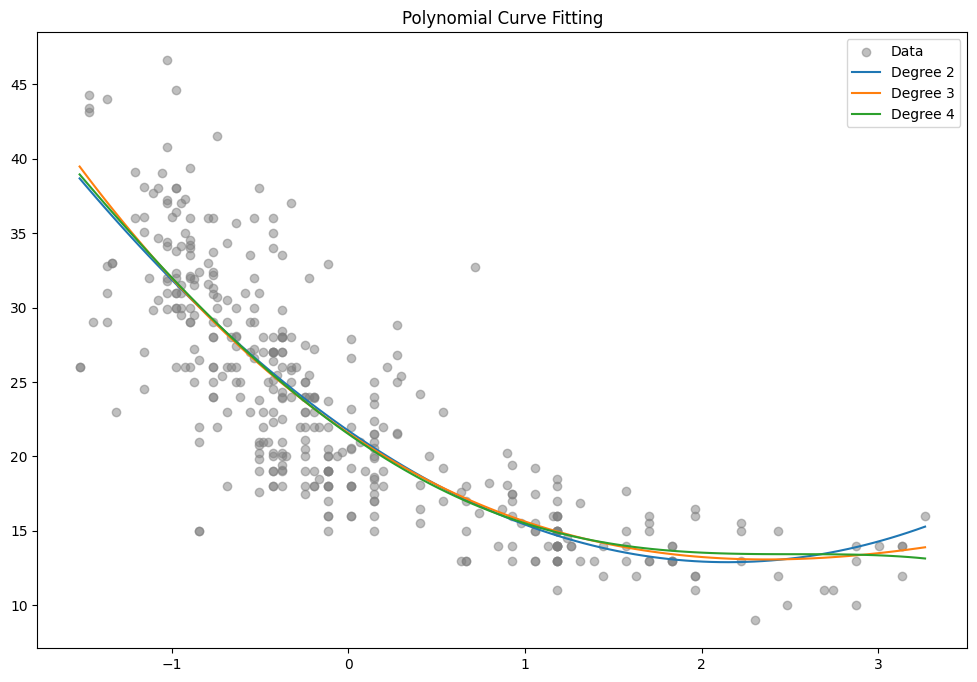

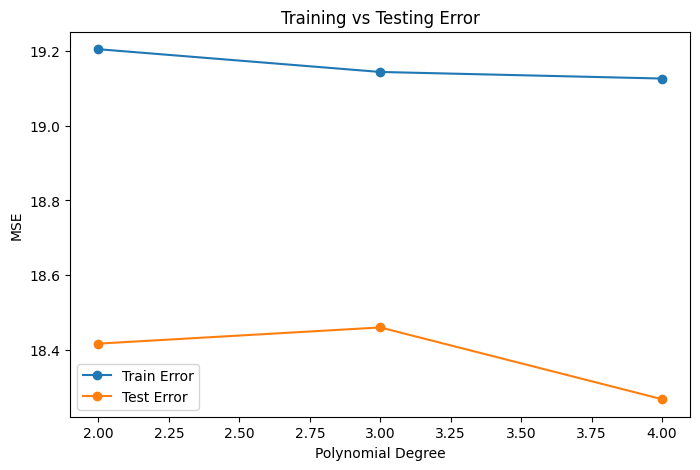

Ridge Regression R2 (Degree 4): 0.6304712092659119


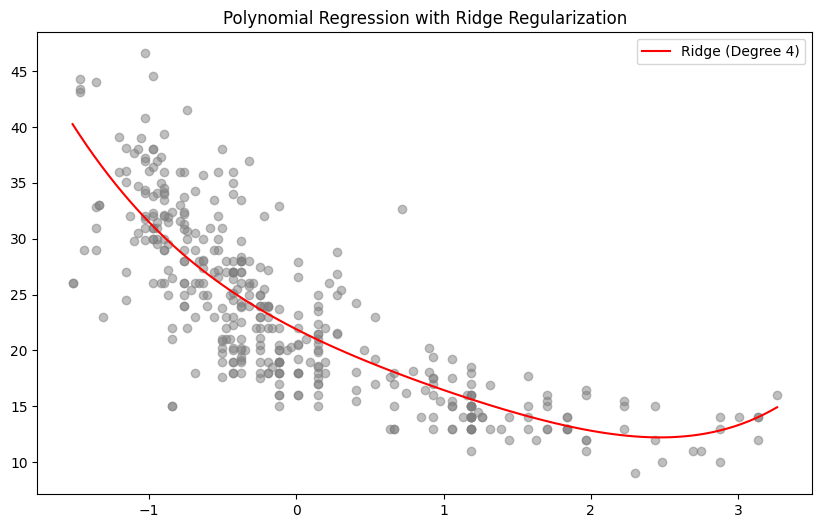

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

print("SHAILESH GOWTHAM - 24BAD108")

df = pd.read_csv('auto-mpg.csv', na_values='?')

df = df.dropna()

df['horsepower'] = pd.to_numeric(df['horsepower'])

X = df[['horsepower']]
y = df['mpg']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

degrees = [2, 3, 4]
train_errors = []
test_errors = []

plt.figure(figsize=(12, 8))
plt.scatter(X_scaled, y, color='gray', alpha=0.5, label='Data')

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    y_train_pred = poly_model.predict(X_train_poly)
    y_test_pred = poly_model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_test_pred)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mse)

    print(f"Degree {d} - MSE: {mse}, RMSE: {rmse}, R2: {r2}")

    X_range = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range_pred = poly_model.predict(X_range_poly)
    plt.plot(X_range, y_range_pred, label=f'Degree {d}')

plt.title('Polynomial Curve Fitting')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, marker='o', label='Train Error')
plt.plot(degrees, test_errors, marker='o', label='Test Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Training vs Testing Error')
plt.legend()
plt.show()

poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train_poly, y_train)
print("Ridge Regression R2 (Degree 4):", ridge_model.score(X_test_poly, y_test))

X_range = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_ridge_pred = ridge_model.predict(X_range_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled, y, color='gray', alpha=0.5)
plt.plot(X_range, y_ridge_pred, color='red', label='Ridge (Degree 4)')
plt.title('Polynomial Regression with Ridge Regularization')
plt.legend()
plt.show()
